In [3]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

from adjustText import adjust_text

#Loading data
dataset = load_dataset ('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


def clean_list(skill_list):
 if pd.notna(skill_list):
    return ast.literal_eval(skill_list)

df['job_skills']= df['job_skills'].apply(clean_list)

c:\Users\hp\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\hp\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Fri Apr 17 15:59:23 2026).


In [4]:
df_USA = df[(df['job_country'] == 'United States')].dropna(subset=['salary_year_avg'])

In [5]:
job_titles = df_USA['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [6]:
df_USA_top6 =  df_USA[df_USA['job_title_short'].isin(job_titles)]

In [7]:
job_order = df_USA_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

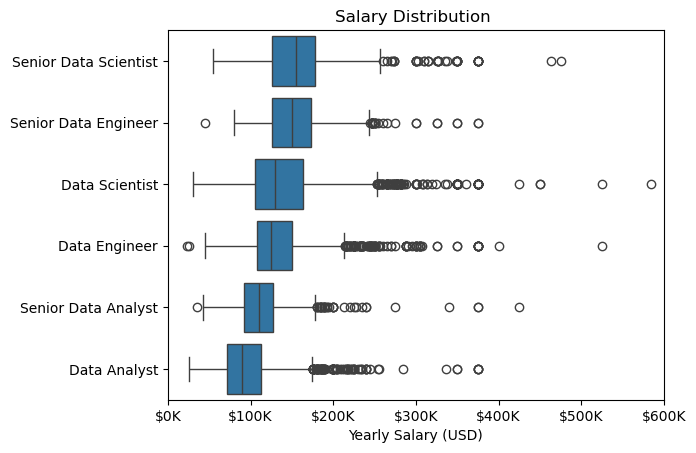

In [8]:
sns.boxplot(data = df_USA_top6 , x = 'salary_year_avg', y = 'job_title_short' , order = job_order)

plt.title('Salary Distribution ')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter( lambda x,_: f'${int (x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

Investigate Median Salary vs Skill for Data Analysts

In [9]:

df_DA_USA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_USA = df_DA_USA.dropna(subset=['salary_year_avg'])

df_DA_USA.explode('job_skills')

df_DA_USA = df_DA_USA.explode('job_skills')

df_DA_USA[['salary_year_avg','job_skills']].head(5)


,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [10]:
df_DA_USA.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_USA_group = df_DA_USA.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_top_pay = df_DA_USA_group.sort_values( by = 'median' , ascending = False).head(10)

df_DA_top_pay

,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [11]:
df_DA_top_skills = df_DA_USA_group.sort_values( by = 'count' , ascending = False).head(10).sort_values( by = 'median' , ascending = False)

df_DA_top_skills 
 

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


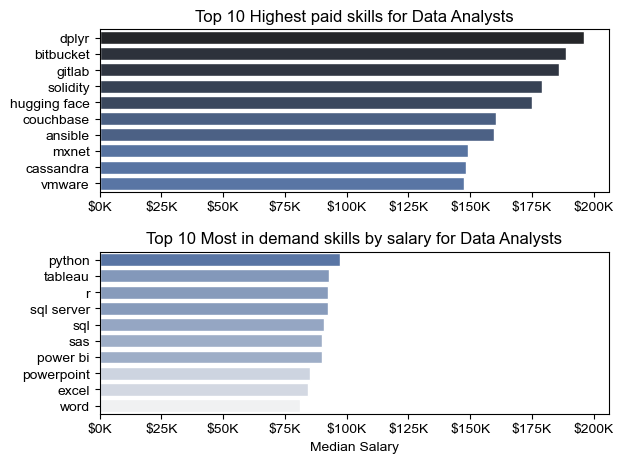

In [ ]:
fig , ax = plt.subplots(2,1)

sns.set_theme(style = 'ticks')

# top 10 highest paid skills for data analysists

sns.barplot( data = df_DA_top_pay, x = 'median', y = df_DA_top_pay.index, ax =ax[0], hue = 'median', palette = 'dark:b_r')
ax[0].legend().remove()
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].set_title('Top 10 Highest paid skills for Data Analysts') 
ax[0].xaxis.set_major_formatter(plt.FuncFormatter( lambda x,_: f'${int (x/1000)}K'))

# Top 10 most in demand skills for data analysts

sns.barplot( data = df_DA_top_skills, x = 'median', y = df_DA_top_skills.index, ax =ax[1], hue = 'median',palette = 'light:b' )
ax[1].legend().remove()
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary')
ax[1].set_title('Top 10 Most in demand skills by salary for Data Analysts') 
ax[1].xaxis.set_major_formatter(plt.FuncFormatter( lambda x,_: f'${int (x/1000)}K'))

fig.tight_layout()